In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db = mysql.connector.connect(host = "localhost" ,
                            username = "root" ,
                            password = "MySql@2314" ,
                            database = "e-Commerce")

cur = db.cursor()

# List all unique cities where customers are located.

In [3]:
query = """ select distinct customer_city from customers """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data)
df.head()

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


# Count the number of orders placed in 2017.

In [5]:
query = """ select count(order_id) from orders where year(order_purchase_timestamp) = 2017"""

cur.execute(query)

data = cur.fetchall()

"total orders placed in 2017 are" , data[0][0]

('total orders placed in 2017 are', 45101)

# Find the total sales per category.

In [7]:
query = """ select products.product_category category,
round(sum(payments.payment_value),2) sales
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Category", "Sales"])
df

,Category,Sales
0,Cool Stuff,171.99
1,perfumery,413.31
2,automotive,164.60
3,electronics,604.69
4,HEALTH BEAUTY,171.30
5,Construction Tools Construction,525.15
6,babies,193.01
7,toys,195.55
8,Furniture Decoration,495.10
9,computer accessories,1953.12


# Calculate the percentage of orders that were paid in installments.

In [11]:
query = """ select sum(case when payment_installments >= 1 then 1
else 0 end)/count(*)*100 from payments
"""

cur.execute(query)

data = cur.fetchall()
"Calculate the percentage of orders that were paid in installments is", data[0][0]

('Calculate the percentage of orders that were paid in installments is',
 Decimal('100.0000'))

# Count the number of customers from each state.

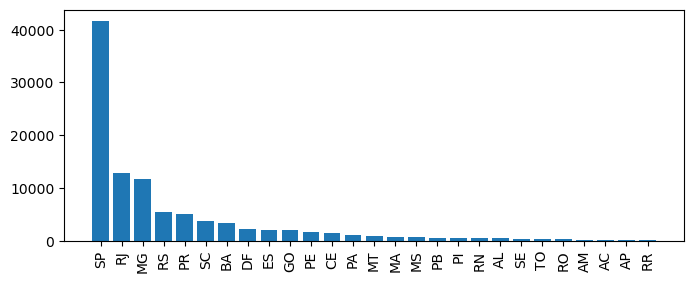

In [6]:
query = """ select customer_state ,count(customer_id)
from customers group by customer_state
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["state", "customer_count" ])
df = df.sort_values(by = "customer_count", ascending = False)

plt.figure(figsize = (8,3))
plt.bar(df["state"], df["customer_count" ])
plt.xticks(rotation = 90)
plt.show()

# Calculate the number of orders per month in 2018.

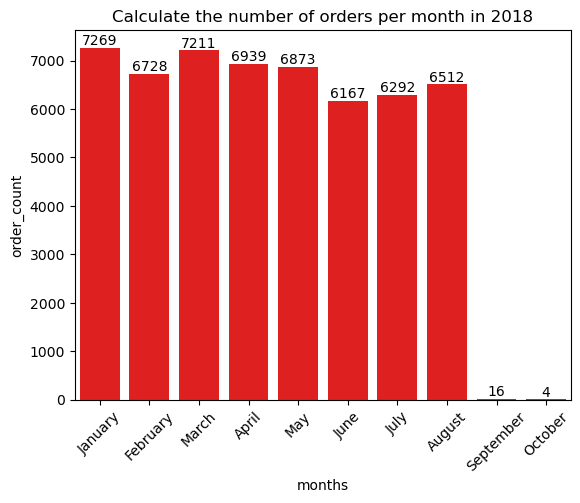

In [5]:
query = """ select monthname(order_purchase_timestamp) months, count(order_id) order_count
from orders where year(order_purchase_timestamp) = 2018
group by months
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["months", "order_count"])
o = ["January", "February", "March", "April", "March", "May", "June", "July", "August", "September", "October"]

ax = sns.barplot(x = df["months"],y = df["order_count"], data = df, order = o, color = "red")
plt.xticks(rotation = 45)
for container in ax.containers:
    for bar in container:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                int(bar.get_height()),
                ha = "center",
                va = "bottom")
#ax.bar_labels(ax.containers[0])
plt.title("Calculate the number of orders per month in 2018")

plt.show()


# Find the average number of products per order, grouped by customer city.

In [19]:
query = """ with count_per_order as
(select orders.order_id, orders.customer_id, count(order_items.order_id) as oc
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id)
select customers.customer_city, round(avg(count_per_order.oc),2) average_orders
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by average_orders desc"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns = ["customer city" , "average orders"])
df.head(10)


,customer city,average orders
0,rio claro,4.00
1,ariquemes,4.00
2,rio verde,4.00
3,passo fundo,3.00
4,campo mourao,3.00
5,sao jose do rio pardo,3.00
6,ferraz de vasconcelos,2.50
7,sao caetano do sul,2.00
8,santo antonio de padua,2.00
9,arapiraca,2.00


# Calculate the percentage of total revenue contributed by each product category.

In [22]:
query = """ 
select upper(products.product_category) category,
round((sum(payments.payment_value)/ (select sum(payments.payment_value) from payments))*100,2) sales_percentage
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category order by sales_percentage desc
"""


cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns = ["Category" , "Percentage distribution"])
df.head(10)

,Category,Percentage distribution
0,COMPUTER ACCESSORIES,0.09
1,ELECTRONICS,0.03
2,PERFUMERY,0.02
3,CONSTRUCTION TOOLS CONSTRUCTION,0.02
4,FURNITURE DECORATION,0.02
5,COOL STUFF,0.01
6,AUTOMOTIVE,0.01
7,HEALTH BEAUTY,0.01
8,BABIES,0.01
9,TOYS,0.01


#  Identify the correlation between product price and the number of times a product has been purchased.

In [7]:
import numpy as np
print(np.__version__)

2.3.5


In [10]:
import numpy as np

query = """select products.product_category,
count(order_items.product_id),
round(avg(order_items.price),2)
from products join order_items
on products.product_id = order_items.product_id
group by products.product_category 
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns = ["Category" , "order_count" , "price"])

arr1 = df["order_count"]
arr2 = df["price"]

a = df["order_count"].corr(df["price"])
print("the correlation is" , a)

the correlation is 0.030061869631169025


# Calculate the total revenue generated by each seller, and rank them by revenue.

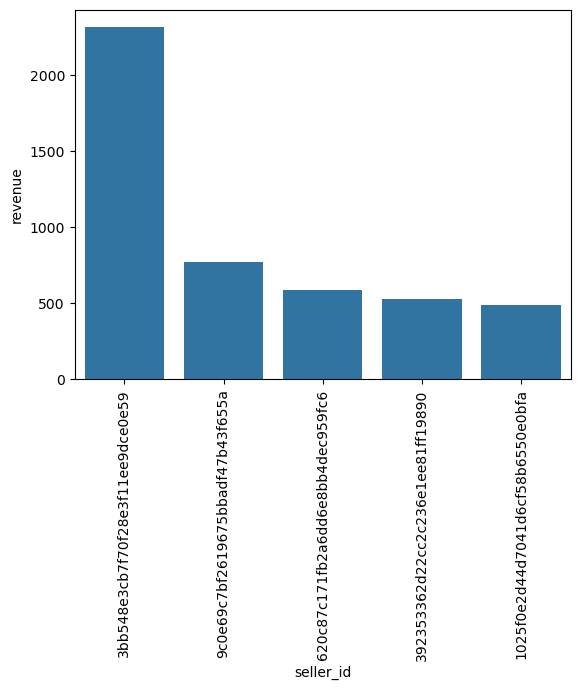

In [32]:
query = """ select *, dense_rank() over(order by revenue desc) as rn from
(select order_items.seller_id, sum(payments.payment_value)
revenue from order_items join payments
on order_items.order_id = payments.order_id
group by order_items.seller_id) as a
"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["seller_id", "revenue", "rank"])
df = df.head()
sns.barplot(x = "seller_id", y = "revenue", data = df)
plt.xticks(rotation = 90)
plt.show()


# Calculate the moving average of order values for each customer over their order history.

In [33]:
query = """ select customer_id, order_purchase_timestamp, payment,
avg(payment)over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from 
(select orders.customer_id, orders.order_purchase_timestamp,
payments.payment_value as payment
from payments join orders
on payments.order_id = orders.order_id) as a
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1,2,3
0,0004164d20a9e969af783496f3408652,2017-04-12 08:35:12,71.80,71.80
1,001051abfcfdbed9f87b4266213a5df1,2018-05-30 09:19:31,13.35,13.35
2,001df1ee5c36767aa607001ab1a13a06,2018-08-05 23:14:45,42.86,42.86
3,001f35d9f262c558fd065346fbf5801d,2018-01-25 17:33:55,46.53,46.53
4,002450e9ea44cb90b8a07ba0b197e149,2017-08-16 09:07:13,40.00,40.00
...,...,...,...,...
14091,ffef8c44b23871ffd6a1df761bd61783,2018-01-20 11:39:38,84.59,84.59
14092,fff168ca1f8a1d2e8e2108b231a68a8c,2018-07-20 16:25:59,70.76,70.76
14093,fff3a5c6d542d52b05f7e4518adf996e,2018-02-18 21:48:22,5.33,5.33
14094,fff7466a253c0e59499ea943462c10f9,2018-02-14 13:22:12,166.19,166.19


# Calculate the cumulative sales per month for each year.

In [34]:
query = """ select years, months , payment , sum(payment)
over(order by years, months) cumulative_sales from
(select year(orders.order_purchase_timestamp) as years,
month(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value),2) as payment from orders join payments
on orders.order_id = payments.order_id
group by years, months order by years, months) as a 
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1,2,3
0,2016,10,6171.55,6171.55
1,2017,1,17091.27,23262.82
2,2017,2,40386.32,63649.14
3,2017,3,56426.25,120075.39
4,2017,4,51109.92,171185.31
5,2017,5,76016.46,247201.77
6,2017,6,74216.42,321418.19
7,2017,7,76812.03,398230.22
8,2017,8,94232.59,492462.81
9,2017,9,87591.98,580054.79


# Calculate the year-over-year growth rate of total sales.

In [38]:
query = """with a as(select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value),2) as payment from orders join payments
on orders.order_id = payments.order_id
group by years order by years)

select years, ((payment - lag(payment, 1) over(order by years))/
lag(payment, 1) over(order by years)) *100 from a
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years","yoy % growth"])
df

,years,yoy % growth
0,2016,NaN
1,2017,15554.712187
2,2018,23.566860


# Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [39]:
query = """ with a as (select customers.customer_id,
min(orders.order_purchase_timestamp) first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),
 
b as (select a.customer_id, count(distinct orders.order_purchase_timestamp) next_order
from a join orders 
on orders.customer_id = a.customer_id 
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp < 
date_add(first_order, interval 6 month)
group by a.customer_id) 

select 100 * (count(distinct a.customer_id)/ count(distinct b.customer_id))
from a left join b
on a.customer_id = b.customer_id ; 
"""

cur.execute(query)
data = cur.fetchall()
data

[(None,)]

#  Identify the top 3 customers who spent the most money in each year.

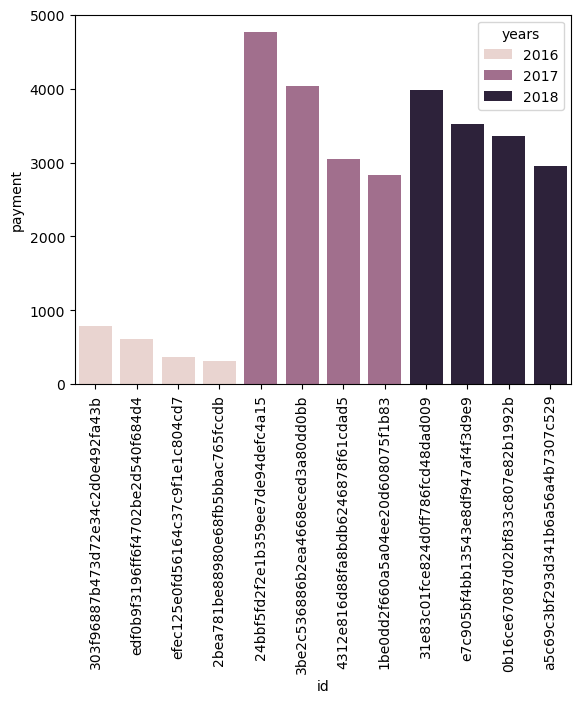

In [42]:
query = """select years, customer_id, payment, d_rank
from
(select year(orders.order_purchase_timestamp) years,
orders.customer_id,
sum(payments.payment_value) payment,
dense_rank() over (partition by  year(orders.order_purchase_timestamp) 
order by sum(payments.payment_value) desc) d_rank
from orders join payments
on payments.order_id = orders.order_id
group by year(orders.order_purchase_timestamp),
orders.customer_id) as a
where d_rank <= 4 
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years", "id", "payment", "rank"])
sns.barplot(x = "id", y = "payment", data = df, hue = "years")
plt.xticks(rotation = 90)
plt.show()